<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_GO_Data_MBFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import re
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import wandb
import pandas as pd
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

In [2]:
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 4.33 MiB/s, done.


In [3]:
seqfile = "expr5Tseq_filtGO_100-1000.lis"

ids, seqs = [], []
with open(seqfile) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if "\t" in line:
            pid, s = line.split("\t", 1)
        else:
            m = re.match(r"^([^A-Z]+)([A-Z].*)$", line)
            if not m:
                continue
            pid, s = m.group(1), m.group(2)
        ids.append(pid.strip())
        seqs.append(s.strip())

go_terms = [
    ("GO_3A0005739.annotprot", "mitochondrion"),
    ("GO_3A0007165.annotprot", "signal_transduction"),
    ("GO_3A0005576.annotprot", "extracellular"),
    ("GO_3A0055085.annotprot", "transmembrane"),
    ("GO_3A0043066.annotprot", "neg_apoptosis"),
]

id2idx = {pid: i for i, pid in enumerate(ids)}
labels = np.zeros((len(ids), len(go_terms)), dtype=np.float32)

for col, (fname, _) in enumerate(go_terms):
    with open(fname) as f:
        pos_ids = [l.strip() for l in f if l.strip()]
    for pid in pos_ids:
        if pid in id2idx:
            labels[id2idx[pid], col] = 1.0

labels = torch.tensor(labels)

In [4]:
mapaa2num = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}

def tokenize_seq(seq, map2num, non_aa_num=20):
    return [map2num.get(ch, non_aa_num) for ch in seq]

def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def build_seq_array(seqs, num_steps, non_aa_num=20):
    return torch.tensor([truncate_pad(s, num_steps, non_aa_num) for s in seqs], dtype=torch.long)

num_steps = 1000
X = build_seq_array([tokenize_seq(s, mapaa2num) for s in seqs], num_steps)

In [5]:
perm = torch.randperm(len(X))
n_train = int(0.7 * len(X))
n_val = int(0.15 * len(X))

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

X_train, y_train = X[train_idx], labels[train_idx]
X_val, y_val = X[val_idx], labels[val_idx]
X_test, y_test = X[test_idx], labels[test_idx]

In [6]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [7]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs_list, y_list = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs_list.append(probs)
        y_list.append(yb.numpy())
    return np.vstack(probs_list), np.vstack(y_list)

def multilabel_metrics(y_true, y_prob):
    out = {}
    out["mAUPRC"] = float(np.mean([
        average_precision_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if y_true[:, i].sum() > 0
    ]))
    out["mAUROC"] = float(np.mean([
        roc_auc_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if len(np.unique(y_true[:, i])) > 1
    ]))
    out["micro_F1"] = float(f1_score(
        y_true.ravel(),
        (y_prob.ravel() >= 0.5).astype(int),
        zero_division=0
    ))
    return out

def plot_multilabel_confusion_matrices(y_true, y_prob, go_terms, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cms = multilabel_confusion_matrix(y_true, y_pred)

    n = len(go_terms)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (_, name) in enumerate(go_terms):
        cm = cms[i]
        ax = axes[i]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(name)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["True 0", "True 1"])

        for r in range(2):
            for c in range(2):
                ax.text(c, r, int(cm[r, c]), ha="center", va="center", color="black")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

def multilabel_metrics(y_true, y_prob):
    out = {}
    out["mAUPRC"] = float(np.mean([
        average_precision_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if y_true[:, i].sum() > 0
    ]))
    out["mAUROC"] = float(np.mean([
        roc_auc_score(y_true[:, i], y_prob[:, i])
        for i in range(y_true.shape[1])
        if len(np.unique(y_true[:, i])) > 1
    ]))
    out["micro_F1"] = float(f1_score(y_true.ravel(), (y_prob.ravel() >= 0.5).astype(int), zero_division=0))
    return out

In [8]:
class ProteinCNN(nn.Module):
    def __init__(self, vocab_size=21, emb_dim=64, conv_channels=128, dropout=0.1, n_labels=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, emb_dim, padding_idx=vocab_size)
        self.net = nn.Sequential(
            nn.Conv1d(emb_dim, conv_channels, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=8, padding=4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten(),
            nn.Linear(conv_channels, n_labels),
        )

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        return self.net(x)

In [9]:
!pip install wandb -q

In [10]:
wandb.init(
    project="protein-go-prediction",
    name="cnn-run-width",
    config={
        "model": "CNN",
        "dropout": 0.1,
        "lr": 1e-3,
        "batch_size": 32,
        "num_steps": 1000,
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shreyas-ba14 (shreyas-ba14-wageningen-academic-publishers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
pos = y_train.sum(0)
neg = y_train.size(0) - pos
pos_weight = (neg / pos.clamp(min=1)).to(device)

torch.manual_seed(0)
net = ProteinCNN(dropout=0.3, n_labels=labels.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-2)

best_val = -1
best_state = None
patience = 5
wait = 0

for epoch in range(1, 26):
    net.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = net(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss = evaluate_loss(net, val_loader, criterion)

    val_probs, val_true = predict_probs(net, val_loader)
    val_metrics = multilabel_metrics(val_true, val_probs)

    wandb.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "val/loss": val_loss,
        "val/mAUPRC": val_metrics["mAUPRC"],
        "val/mAUROC": val_metrics["mAUROC"],
        "val/micro_F1": val_metrics["micro_F1"],
    })

    for i, (_, name) in enumerate(go_terms):
        wandb.log({
            f"val/AUROC_{name}": roc_auc_score(val_true[:, i], val_probs[:, i]),
            f"val/AUPRC_{name}": average_precision_score(val_true[:, i], val_probs[:, i]),
        })

    print(f"epoch {epoch:02d} train loss {train_loss:.4f} val loss {val_loss:.4f} val mAUPRC {val_metrics['mAUPRC']:.4f}")

    if val_metrics["mAUPRC"] > best_val:
        best_val = val_metrics["mAUPRC"]
        best_state = copy.deepcopy(net.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break

net.load_state_dict(best_state)

epoch 01 train loss 1.3509 val loss 1.3973 val mAUPRC 0.1528
epoch 02 train loss 1.2723 val loss 1.3411 val mAUPRC 0.1733
epoch 03 train loss 1.2057 val loss 1.2958 val mAUPRC 0.1797
epoch 04 train loss 1.1409 val loss 1.2990 val mAUPRC 0.1899
epoch 05 train loss 1.0874 val loss 1.2757 val mAUPRC 0.2142
epoch 06 train loss 1.0270 val loss 1.2414 val mAUPRC 0.2198
epoch 07 train loss 0.9912 val loss 1.1982 val mAUPRC 0.2368
epoch 08 train loss 0.9144 val loss 1.2273 val mAUPRC 0.2424
epoch 09 train loss 0.8788 val loss 1.1963 val mAUPRC 0.2453
epoch 10 train loss 0.8203 val loss 1.1835 val mAUPRC 0.2579
epoch 11 train loss 0.7768 val loss 1.2266 val mAUPRC 0.2591
epoch 12 train loss 0.7253 val loss 1.2712 val mAUPRC 0.2615
epoch 13 train loss 0.6487 val loss 1.2616 val mAUPRC 0.2609
epoch 14 train loss 0.6212 val loss 1.2648 val mAUPRC 0.2650
epoch 15 train loss 0.5627 val loss 1.3058 val mAUPRC 0.2691
epoch 16 train loss 0.5390 val loss 1.3237 val mAUPRC 0.2661
epoch 17 train loss 0.49

<All keys matched successfully>

### Accuracy per GO Term on Training Set

/tmp/ipykernel_531/4231576178.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df_train, palette="viridis")


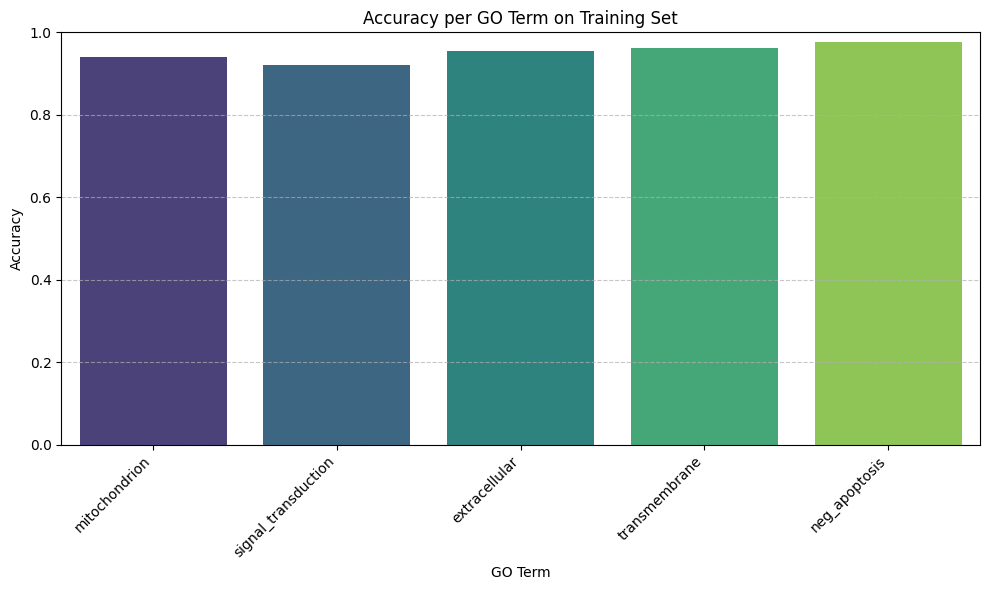

In [16]:
train_probs, train_true = predict_probs(net, train_loader)

accuracy_scores_per_label_train = []
for i, (_, name) in enumerate(go_terms):
    acc_train = accuracy_score(train_true[:, i], (train_probs[:, i] >= 0.5).astype(int))
    accuracy_scores_per_label_train.append({"GO Term": name, "Accuracy": acc_train})

accuracy_df_train = pd.DataFrame(accuracy_scores_per_label_train)

plt.figure(figsize=(10, 6))
sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df_train, palette="viridis")
plt.title("Accuracy per GO Term on Training Set")
plt.xlabel("GO Term")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Evaluate Model on Test Set

In [17]:
test_probs, test_true = predict_probs(net, test_loader)
test_metrics = multilabel_metrics(test_true, test_probs)

print(f"Test mAUPRC: {test_metrics['mAUPRC']:.4f}")
print(f"Test mAUROC: {test_metrics['mAUROC']:.4f}")
print(f"Test micro F1: {test_metrics['micro_F1']:.4f}")

wandb.log({
    "test/mAUPRC": test_metrics["mAUPRC"],
    "test/mAUROC": test_metrics["mAUROC"],
    "test/micro_F1": test_metrics["micro_F1"],
})

for i, (_, name) in enumerate(go_terms):
    wandb.log({
        f"test/AUROC_{name}": roc_auc_score(test_true[:, i], test_probs[:, i]),
        f"test/AUPRC_{name}": average_precision_score(test_true[:, i], test_probs[:, i]),
    })

Test mAUPRC: 0.2548
Test mAUROC: 0.7349
Test micro F1: 0.2927


### Accuracy per GO Term

/tmp/ipykernel_531/1299341180.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df, palette="viridis")


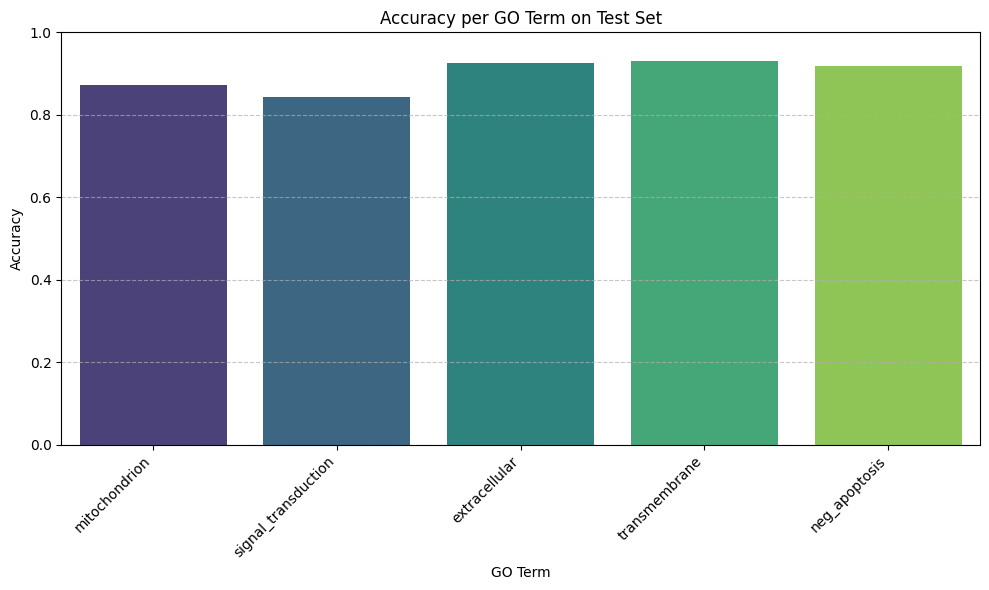

In [18]:
accuracy_scores_per_label = []
for i, (_, name) in enumerate(go_terms):
    acc = accuracy_score(test_true[:, i], (test_probs[:, i] >= 0.5).astype(int))
    accuracy_scores_per_label.append({"GO Term": name, "Accuracy": acc})

accuracy_df = pd.DataFrame(accuracy_scores_per_label)

plt.figure(figsize=(10, 6))
sns.barplot(x="GO Term", y="Accuracy", data=accuracy_df, palette="viridis")
plt.title("Accuracy per GO Term on Test Set")
plt.xlabel("GO Term")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrices for Each GO Term

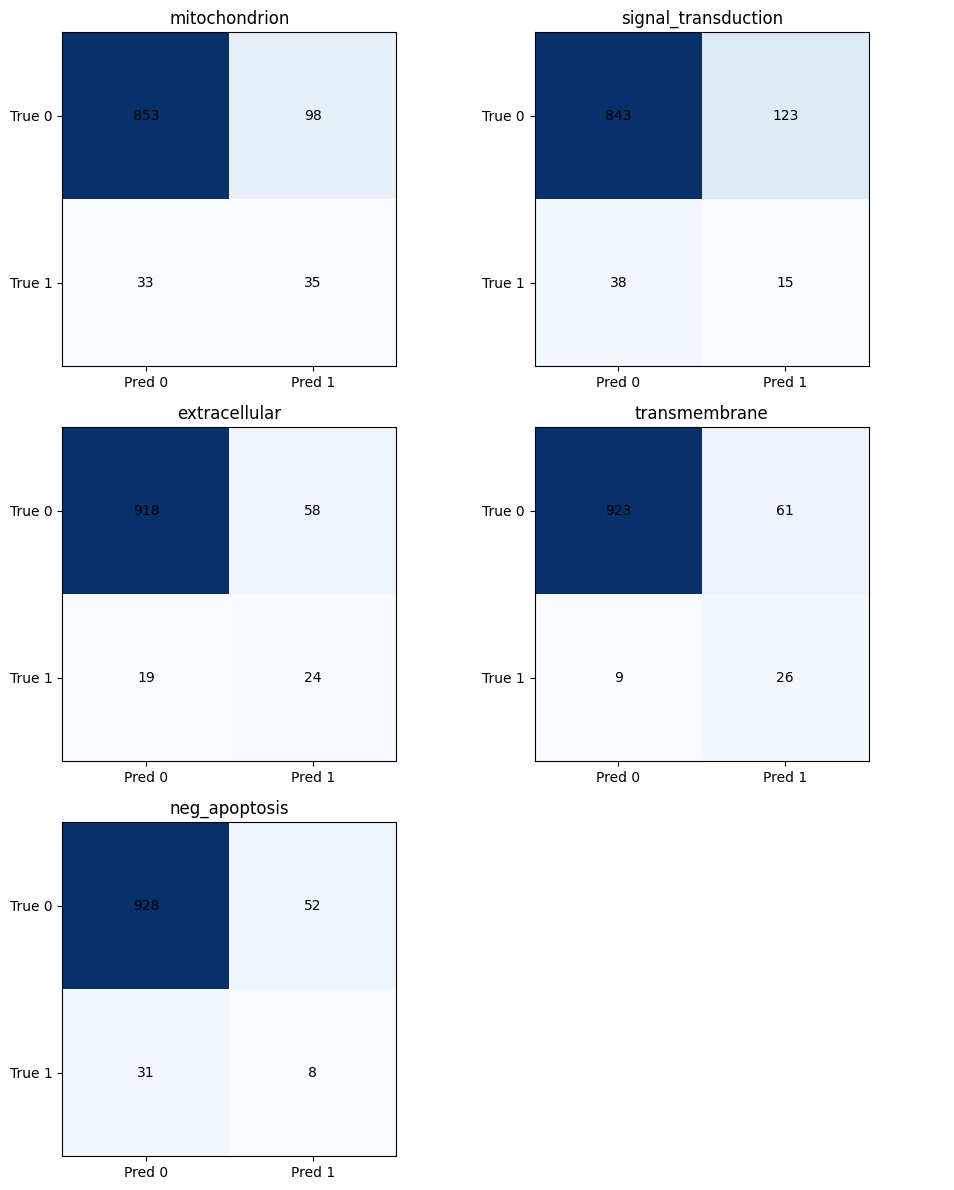

In [19]:
plot_multilabel_confusion_matrices(test_true, test_probs, go_terms)

In [20]:
wandb.finish()

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test/AUPRC_extracellular,▁
test/AUPRC_mitochondrion,▁
test/AUPRC_neg_apoptosis,▁
test/AUPRC_signal_transduction,▁
test/AUPRC_transmembrane,▁
test/AUROC_extracellular,▁
test/AUROC_mitochondrion,▁
test/AUROC_neg_apoptosis,▁
test/AUROC_signal_transduction,▁
+19,...
